<a href="https://colab.research.google.com/github/ricardoVergani/cp-vc-foods/blob/main/checkpoint_food101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint — Classificação de Imagens + Deploy

Leia o `README.md` antes de começar.


In [5]:
from pathlib import Path

DATASET_ROOT = Path.cwd() / "food101_dataset"

CLASSES = [
    "apple_pie",
    "baklava",
    "beef_carpaccio",
    "beef_tartare",
    "beet_salad",
    "beignets",
]
TRAIN_PER_CLASS = 120
VAL_PER_CLASS = 40
TEST_PER_CLASS = 40

# Adjusting paths for the nested directory structure after unzipping
NESTED_DATASET_ROOT = DATASET_ROOT / "food101_dataset"
TRAIN_DIR = NESTED_DATASET_ROOT / "train"
VAL_DIR = NESTED_DATASET_ROOT / "val"
TEST_DIR = NESTED_DATASET_ROOT / "test"

# Ensure the root directory exists before any operations
DATASET_ROOT.mkdir(parents=True, exist_ok=True)

print("Dataset root:", DATASET_ROOT)
print("Nested Dataset root:", NESTED_DATASET_ROOT)
print("Existe:", DATASET_ROOT.exists())
print("Classes:", CLASSES)
# As o Dataset ainda não foi descompactado, os diretórios de treino, validação e teste não existem ainda.
# As informações sobre o número de pastas serão exibidas após a descompactação na próxima célula.

Dataset root: /content/food101_dataset
Existe: True
Classes: ['apple_pie', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets']


In [4]:
import zipfile

zip_file_path = '/content/food101_dataset.zip'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(DATASET_ROOT)

print(f"Conteúdo de '{zip_file_path}' descompactado para '{DATASET_ROOT}'")
# Agora que o dataset foi descompactado, podemos verificar o número de pastas.
print("Train folders após descompactação:", len(list(TRAIN_DIR.iterdir())) if TRAIN_DIR.exists() else 0)
print("Val folders após descompactação:", len(list(VAL_DIR.iterdir())) if VAL_DIR.exists() else 0)
print("Test folders após descompactação:", len(list(TEST_DIR.iterdir())) if TEST_DIR.exists() else 0)

Conteúdo de '/content/food101_dataset.zip' descompactado para '/content/food101_dataset'
Train folders após descompactação: 0
Val folders após descompactação: 0
Test folders após descompactação: 0


## Sua solução

A partir daqui, desenvolva sua solução. Adicione quantas células forem necessárias.

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Configurações de dimensão e batch
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. Carregar Dataset de Treino e criar divisão de Validação (20%)
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 2. Carregar Dataset de Teste
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = raw_train_ds.class_names
print("Classes detectadas:", class_names)

# 3. Augmentação de Dados para evitar overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

train_ds = raw_train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Otimização de pipeline de dados
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 720 files belonging to 6 classes.
Using 576 files for training.
Found 720 files belonging to 6 classes.
Using 144 files for validation.
Found 240 files belonging to 6 classes.
Classes detectadas: ['apple_pie', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets']


In [17]:
# Pré-processamento específico da arquitetura MobileNetV2
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Carregar modelo base pré-treinado no ImageNet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

# Congelar a base pré-treinada
base_model.trainable = False

# Montar a cabeça de classificação
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compilar o modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
# Configurar Callbacks para parar precocemente se estagnar e salvar o melhor resultado
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2),
    tf.keras.callbacks.ModelCheckpoint('food101_model.keras', save_best_only=True)
]

# Treinamento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.2917 - loss: 1.8219 - val_accuracy: 0.5000 - val_loss: 1.3204 - learning_rate: 0.0010
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 448ms/step - accuracy: 0.5069 - loss: 1.2512 - val_accuracy: 0.5556 - val_loss: 1.0799 - learning_rate: 0.0010
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 397ms/step - accuracy: 0.6111 - loss: 1.0020 - val_accuracy: 0.6250 - val_loss: 0.9437 - learning_rate: 0.0010
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 447ms/step - accuracy: 0.6858 - loss: 0.8609 - val_accuracy: 0.6528 - val_loss: 0.8588 - learning_rate: 0.0010
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 402ms/step - accuracy: 0.6823 - loss: 0.8257 - val_accuracy: 0.6806 - val_loss: 0.8473 - learning_rate: 0.0010
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 433ms/step - accuracy: 0.7309 - loss: 0.7071 - val_accuracy: 0.6944 - val_loss: 0.7958 - learning_rate: 0.0010
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 446ms/step - accuracy: 0.7552 - loss: 0.6850 - va

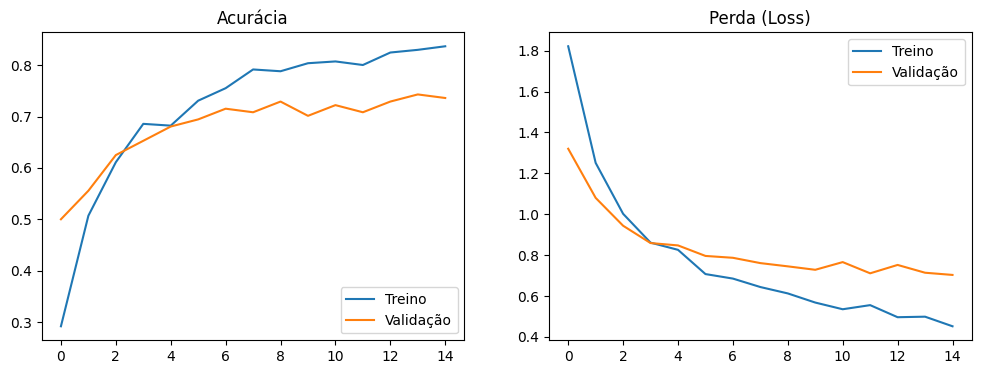

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7667 - loss: 0.6007

--- Acurácia Final no Teste: 76.67% ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 620ms/step

Relatório de Classificação:
                precision    recall  f1-score   support

     apple_pie       0.73      0.60      0.66        40
       baklava       0.73      0.80      0.76        40
beef_carpaccio       0.83      0.75      0.79        40
  beef_tartare       0.82      0.68      0.74        40
    beet_salad       0.67      0.82      0.74        40
      beignets       0.84      0.95      0.89        40

      accuracy                           0.77       240
     macro avg       0.77      0.77      0.76       240
  weighted avg       0.77      0.77      0.76       240



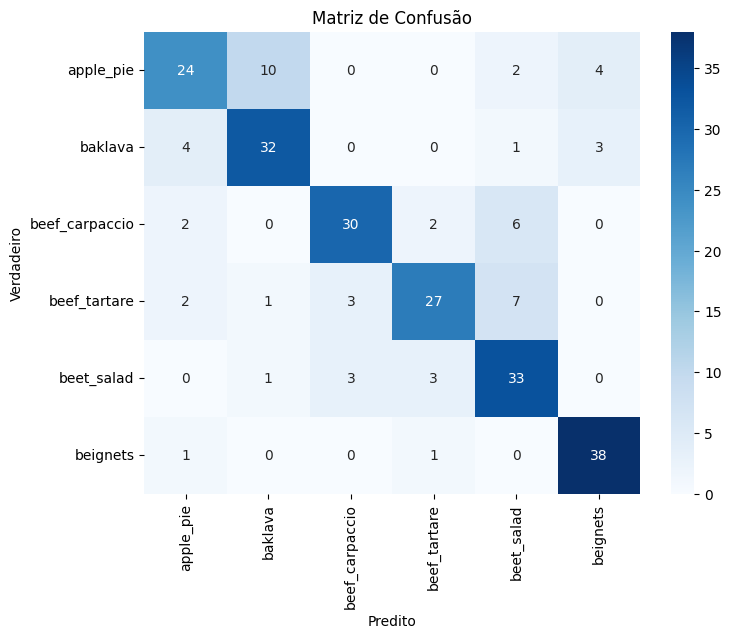

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Gráficos de Perda e Acurácia
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Treino')
plt.plot(val_acc, label='Validação')
plt.legend(loc='lower right')
plt.title('Acurácia')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Treino')
plt.plot(val_loss, label='Validação')
plt.legend(loc='upper right')
plt.title('Perda (Loss)')
plt.show()

# 2. Avaliação no Conjunto de Teste
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n--- Acurácia Final no Teste: {test_acc*100:.2f}% ---")

# 3. Matriz de Confusão e Classification Report
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

In [ ]:
# Instala o Gradio para criar o Web Deploy
!pip install -q gradio

import gradio as gr

def predict_food(image):
    if image is None:
        return None
    # Converter para tensor e redimensionar
    img = tf.image.resize(image, IMG_SIZE)
    img_array = tf.expand_dims(img, axis=0)

    # Realizar a predição
    predictions = model.predict(img_array)[0]

    # Retornar probabilidades formatadas para o Gradio
    return {class_names[i]: float(predictions[i]) for i in range(len(class_names))}

# Criando a interface gráfica
demo = gr.Interface(
    fn=predict_food,
    inputs=gr.Image(type="numpy", label="Envie uma imagem do prato"),
    outputs=gr.Label(num_top_classes=3, label="Resultado da Classificação"),
    title="Classificador de Pratos",
    description="Faça upload de uma foto de um dos 6 pratos (`apple_pie`, `baklava`, `beef_carpaccio`, `beef_tartare`, `beet_salad`, `beignets`) para ver a classificação da Inteligência Artificial."
)

# Lançar o Deploy (share=True gera um link público acessível por qualquer pessoa)
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a117db5400f4f270e4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
